In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

In [2]:
data = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_training_dataset.csv")
data.head()

,building_type,climate_zone,budget_level,area_sqft,floors,ceiling_height,occupancy,operating_hours,building_age,outdoor_temp,humidity,insulation,glass_ratio,recommended_hvac
0,Residential,NaN,Medium,1021.68,1.0,8.47,28.0,11.0,29.0,33.32,83.40,Good,Low,Central Chiller
1,Office,Hot,Low,500.00,1.0,10.19,42.0,11.0,13.0,48.24,43.94,Poor,High,VRF
2,Industrial,Humid,Low,90186.19,4.0,21.60,4494.0,14.0,12.0,32.08,88.89,Average,Low,VRF
3,Residential,NaN,Medium,2316.93,1.0,8.27,34.0,7.0,1.0,42.36,95.71,Good,Low,Split AC
4,Residential,Hot,Medium,705.85,1.0,8.04,16.0,8.0,9.0,34.64,36.91,Good,Low,Multi-Split


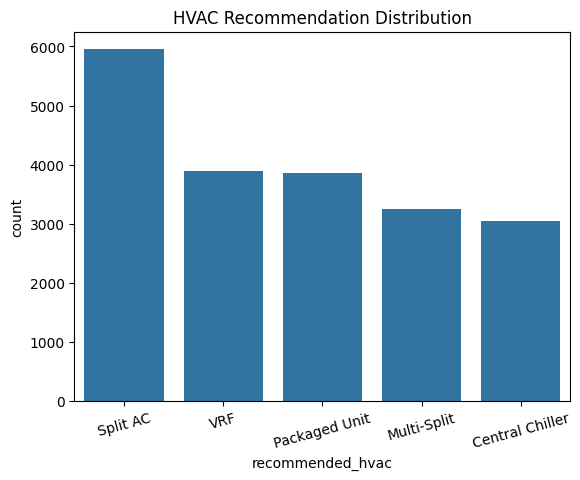

In [3]:
sns.countplot(
    data=data,
    x="recommended_hvac",
    order=data["recommended_hvac"].value_counts().index
)

plt.title("HVAC Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [4]:
print(
    data["recommended_hvac"]
    .value_counts(normalize=True) * 100
)

recommended_hvac
Split AC           29.760
VRF                19.430
Packaged Unit      19.300
Multi-Split        16.235
Central Chiller    15.275
Name: proportion, dtype: float64


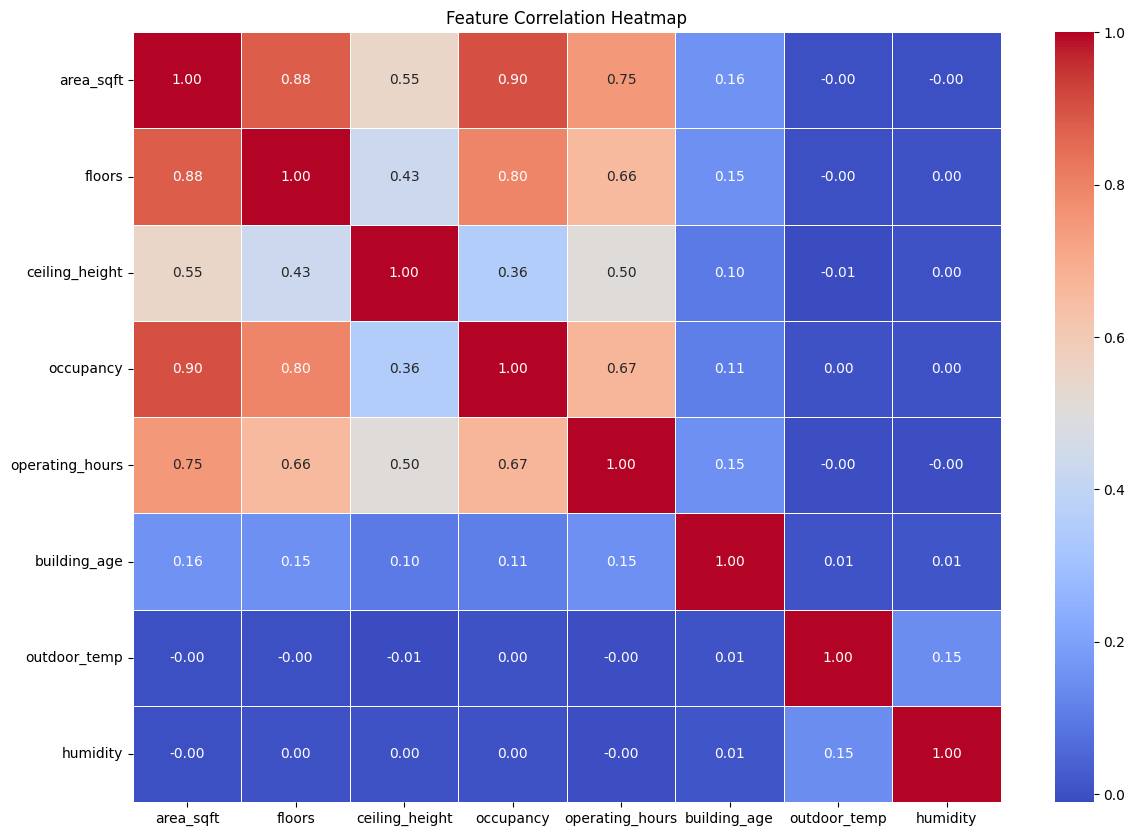

In [5]:
numeric_df = data.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
corr_pairs = corr.unstack()

corr_pairs = corr_pairs.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs != 1]

display(corr_pairs.head(20))

area_sqft        occupancy          0.903747
occupancy        area_sqft          0.903747
floors           area_sqft          0.878622
area_sqft        floors             0.878622
occupancy        floors             0.795003
floors           occupancy          0.795003
area_sqft        operating_hours    0.750071
operating_hours  area_sqft          0.750071
                 occupancy          0.670297
occupancy        operating_hours    0.670297
floors           operating_hours    0.655041
operating_hours  floors             0.655041
ceiling_height   area_sqft          0.549509
area_sqft        ceiling_height     0.549509
operating_hours  ceiling_height     0.504766
ceiling_height   operating_hours    0.504766
floors           ceiling_height     0.430431
ceiling_height   floors             0.430431
occupancy        ceiling_height     0.355611
ceiling_height   occupancy          0.355611
dtype: float64

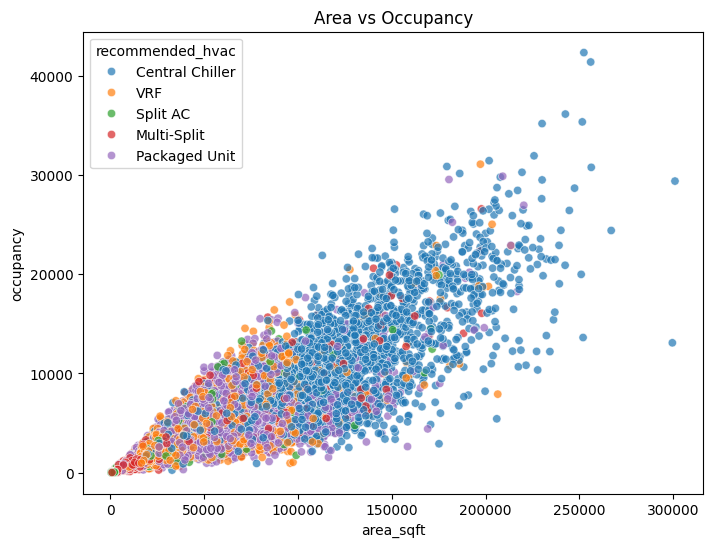

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="area_sqft",
    y="occupancy",
    hue="recommended_hvac",
    alpha=0.7
)

plt.title("Area vs Occupancy")
plt.show()